## Section 1 — Imports
Loads all the libraries needed — **Keras** for building models, **NumPy** for math, and **Matplotlib** for plotting.

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


##  Section 2 — Load & Clean Text Corpus
- Original corpus kept as **reference**
- **Custom NLP paragraph** added for Task #1
- Text **lowercased and stripped** for consistent tokenization

In [14]:


# Task #1 — custom corpus
corpus = '''
natural language processing enables machines to understand human language
word embeddings capture semantic meaning of words in vector space
attention mechanisms allow models to focus on relevant parts of the input
transformers have revolutionized the field of natural language understanding
recurrent models process sequences step by step to learn patterns
language models predict the next token based on previous context
'''

# clean
corpus = corpus.strip().lower()
print(corpus[:200])

natural language processing enables machines to understand human language
word embeddings capture semantic meaning of words in vector space
attention mechanisms allow models to focus on relevant parts


## Section 3 — Tokenization & Sequence Creation
- Each word gets a **unique integer ID**
- **N-gram sequences** built using a sliding window
- Each row ends with the **next word to predict**
- Sequences **padded to equal length**
- Split into **X** (input) and **y** (label)

In [15]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 47
X shape: (54, 11)
y shape: (54,)


##  Section 4 — Build Three Models

### Model 1 — Vanilla RNN
- Simple **baseline** model
- Struggles with **long-range dependencies**
- Suffers from **vanishing gradient problem**


In [16]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


### Model 2 — LSTM
- Uses **3 gates** — input, forget, output
- Retains **long-term memory** effectively
- Best for **complex and longer sequences**


In [17]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — GRU
- Uses **2 gates** — reset, update
- Nearly as good as LSTM but **trains faster**
- Fewer parameters, **lower compute cost**

In [18]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

> Embedding raised **32→64** (Task #2) · Hidden units raised **64→128** (Task #4)

## Section 5 — Train All Three Models
- Same **data, optimizer, and loss function** across all models
- Epochs raised to **200** (Task #3)
- Allows all models to **fully converge**

In [19]:
EPOCHS = 200

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=1)
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=1)
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0000e+00 - loss: 3.8472
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1296 - loss: 3.7603
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2222 - loss: 3.6821
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2963 - loss: 3.6026
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2593 - loss: 3.5257
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2407 - loss: 3.4395
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2037 - loss: 3.3689
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2222 - loss: 3.2839
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2593 - loss: 3.2018
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2963 - loss: 3.1118
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4259 - loss: 3.0194
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4444 

## Section 6 — Compare Training Loss
- Loss curves plotted for all 3 models across **200 epochs**
- **Lower loss = better performance**
- LSTM and GRU expected to reach **lower final loss** than Vanilla RNN

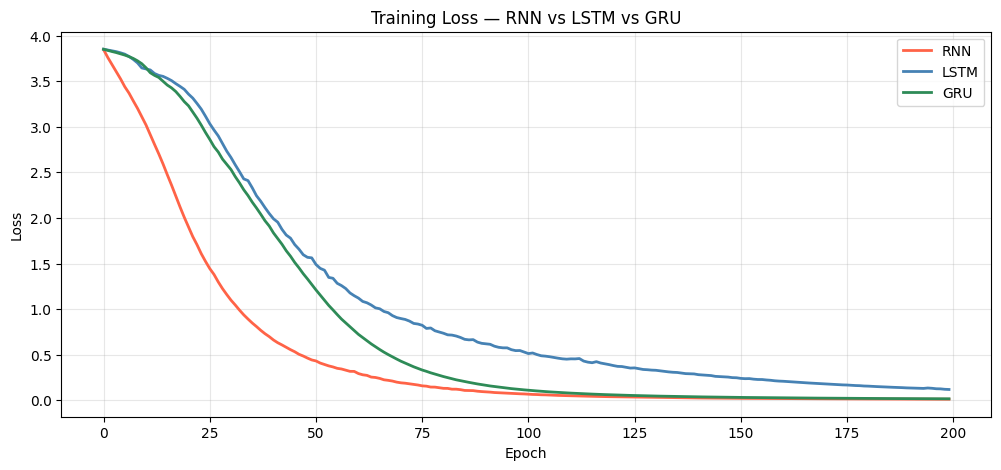

Final Loss → RNN: 0.0110 | LSTM: 0.1180 | GRU: 0.0156


In [20]:
plt.figure(figsize=(12, 5))
plt.plot(rnn_history.history['loss'],  label='RNN',  color='tomato',    linewidth=2)
plt.plot(lstm_history.history['loss'], label='LSTM', color='steelblue', linewidth=2)
plt.plot(gru_history.history['loss'],  label='GRU',  color='seagreen',  linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss — RNN vs LSTM vs GRU")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final Loss → RNN: {rnn_history.history['loss'][-1]:.4f} | LSTM: {lstm_history.history['loss'][-1]:.4f} | GRU: {gru_history.history['loss'][-1]:.4f}")

## Section 7 — Text Generation Function
- Generates text **word by word**
- `model.predict()` outputs a **probability for every word**
- `np.argmax` picks the word with the **highest probability**
- Repeats until **next_words** count is reached

In [21]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted_index = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                seed_text += " " + word
                break
    return seed_text

##  Section 8 — Generate Text Samples
- All three models tested on the **same seed phrase**
- Output extended to **10 words** (Task #5)
- **LSTM and GRU** should produce more coherent text than Vanilla RNN

In [22]:
seed = "natural language"

print("RNN :", generate_text(rnn_model,  seed, next_words=10))
print("LSTM:", generate_text(lstm_model, seed, next_words=10))
print("GRU :", generate_text(gru_model,  seed, next_words=10))

RNN : natural language processing enables machines to understand human language understanding of the
LSTM: natural language processing enables machines to understand human language language context context
GRU : natural language processing enables machines to understand human language understanding the input


##  Conclusion
- **Vanilla RNN** — learns short patterns, fails on long sequences due to **vanishing gradient**
- **LSTM** — best memory retention using **3 gates**, ideal for complex sequences
- **GRU** — **2 gates**, faster than LSTM, nearly same accuracy
- All models improved with **larger embedding (64)**, **wider layers (128)**, and **200 epochs**
- **Custom corpus** gave richer vocabulary and better generated text
- For real-world use, prefer **LSTM or GRU** over Vanilla RNN